In [ ]:
import kagglehub
from kagglehub import KaggleDatasetAdapter
import pandas as pd
import os
import numpy as np
from pathlib import Path
from PIL import Image
import matplotlib.pyplot as plt
import cv2
from sklearn.model_selection import train_test_split
import warnings
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (Conv2D, BatchNormalization, MaxPooling2D,
                                      Dropout, Flatten, Dense)
from tensorflow.keras.optimizers import Adam
from sklearn.utils.class_weight import compute_class_weight
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_curve, classification_report, roc_auc_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import roc_curve, auc
from sklearn.metrics import (roc_auc_score, average_precision_score,
                              confusion_matrix, classification_report,
                              brier_score_loss, log_loss)
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

warnings.filterwarnings('ignore')

dataset_path = kagglehub.dataset_download("abdullahmohsinune/thrombus-vs-non-thrombus-dataset-images")
print("Dataset downloaded to:", dataset_path)
print("Files:", os.listdir(dataset_path))
base_path = Path(dataset_path) 
base_path = base_path / 'ml_data' / 'ml_data'
train_path = base_path / 'TRAIN'
test_path = base_path / 'TEST'
valid_path = base_path / 'VALID'
IMG_SIZE = (224, 224)

Using Colab cache for faster access to the 'thrombus-vs-non-thrombus-dataset-images' dataset.
Dataset downloaded to: /kaggle/input/thrombus-vs-non-thrombus-dataset-images
Files: ['SPLIT', 'ml_data', 'BALANCED_DATASET', 'train.csv', 'test.csv', 'DATA']


In [ ]:
def contar_arquivos(caminho, extensao='.jpg'):
    """Contar arquivos com extensão específica"""
    if not caminho.exists():
        return 0
    return len(list(caminho.glob(f'*{extensao}')))


def preprocessar_imagem(caminho_imagem, tamanho=IMG_SIZE, normalizar=True):
    """
    Pré-processa uma imagem individual
    
    Args:
        caminho_imagem: Caminho da imagem
        tamanho: Tamanho para redimensionar (padrão: 224x224)
        normalizar: Se deve normalizar para [0, 1]
    
    Returns:
        Array numpy com a imagem processada
    """
    try:

        img = Image.open(caminho_imagem).convert('RGB')
        img = img.resize(tamanho, Image.Resampling.LANCZOS)
        arr = np.array(img, dtype=np.float32)
        if normalizar:
            arr = arr / 255.0
        return arr
    except Exception as e:
        print(f"Erro ao processar {caminho_imagem}: {e}")
        return None


def carregar_dataset(split='train'):
    """
    Carrega um dataset completo (train, test ou valid)
    
    Args:
        split: 'train', 'test' ou 'valid'
    
    Returns:
        Tuple (X, y) onde X são as imagens e y são os rótulos
    """
    caminho_split = base_path / split
    imagens = []
    rotulos = []
    # Classe 0: Não Trombose
    classe_path = caminho_split / 'Non-Thrombus'
    for img_file in sorted(classe_path.glob('*.jpg')):
        img = preprocessar_imagem(img_file)
        if img is not None:
            imagens.append(img)
            rotulos.append(0)
    # Classe 1: Trombose
    classe_path = caminho_split / 'Thrombus'
    for img_file in sorted(classe_path.glob('*.jpg')):
        img = preprocessar_imagem(img_file)
        if img is not None:
            imagens.append(img)
            rotulos.append(1)
    X = np.array(imagens)
    y = np.array(rotulos)
    return X, y

def carregar_dados_preprocessados(tipo='completo'):
    """
    Carrega dados pré-processados
    
    Args:
        tipo: 'completo', 'train', 'test' ou 'valid'
    
    Returns:
        X, y (ou todos os splits se tipo='completo')
    """
    output_dir = Path('dados_preprocessados')
    
    if tipo == 'completo':
        data = np.load(output_dir / 'dataset_completo.npz')
        return data['X_train'], data['y_train'], \
               data['X_test'], data['y_test'], \
               data['X_valid'], data['y_valid']
    else:
        data = np.load(output_dir / f'{tipo}.npz')
        return data['X'], data['y']

In [ ]:
datasets = {
    'Train': {'Thrombus': train_path / 'Thrombus', 'Non-Thrombus': train_path / 'Non-Thrombus'},
    'Test': {'Thrombus': test_path / 'Thrombus', 'Non-Thrombus': test_path / 'Non-Thrombus'}
}
summary = {}
for split, classes in datasets.items():
    summary[split] = {}
    for class_name, class_path in classes.items():
        count = contar_arquivos(class_path)
        summary[split][class_name] = count

resumo_df = pd.DataFrame(summary).T
print(resumo_df)
print(f"Total de imagens: {resumo_df.sum().sum()}")
print(f"Trombose: {resumo_df['Thrombus'].sum()}")
print(f"Não Trombose: {resumo_df['Non-Thrombus'].sum()}")

       Thrombus  Non-Thrombus
Train       400           400
Test        100           100
Total de imagens: 1000
Trombose: 500
Não Trombose: 500


Imagem Trombose tamanho original: (594, 516)
Imagem Não Trombose tamanho original: (384, 430)


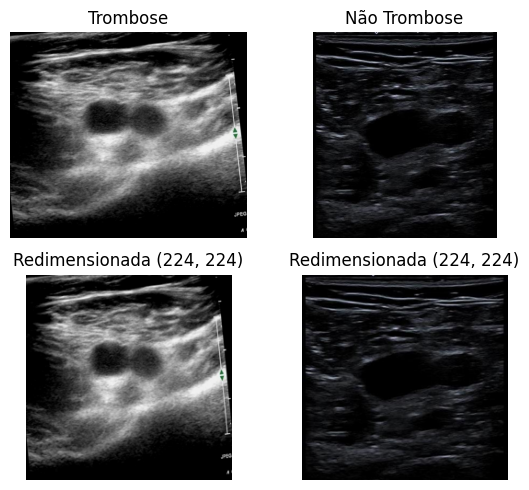

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(6, 5))
thrombus_path = train_path / 'Thrombus' / 'Thrombus_train_109.jpg'
if thrombus_path.exists():
    img_thrombus = Image.open(thrombus_path)
    axes[0, 0].imshow(img_thrombus)
    axes[0, 0].set_title('Trombose')
    axes[0, 0].axis('off')
    print(f"Imagem Trombose tamanho original: {img_thrombus.size}")
non_thrombus_path = train_path / 'Non-Thrombus' / 'Non-Thrombus_train_105.jpg'
if non_thrombus_path.exists():
    img_non_thrombus = Image.open(non_thrombus_path)
    axes[0, 1].imshow(img_non_thrombus)
    axes[0, 1].set_title('Não Trombose')
    axes[0, 1].axis('off')
    print(f"Imagem Não Trombose tamanho original: {img_non_thrombus.size}")
if thrombus_path.exists():
    img_thrombus_resized = img_thrombus.resize(IMG_SIZE)
    axes[1, 0].imshow(img_thrombus_resized)
    axes[1, 0].set_title(f'Redimensionada {IMG_SIZE}')
    axes[1, 0].axis('off')

if non_thrombus_path.exists():
    img_non_thrombus_resized = img_non_thrombus.resize(IMG_SIZE)
    axes[1, 1].imshow(img_non_thrombus_resized)
    axes[1, 1].set_title(f'Redimensionada {IMG_SIZE}')
    axes[1, 1].axis('off')
plt.tight_layout()
plt.show()

In [ ]:
X_train, y_train = carregar_dataset('TRAIN')
print(f"Train: {X_train.shape[0]} imagens | Shape: {X_train.shape}")
X_test, y_test = carregar_dataset('TEST')
print(f"Test: {X_test.shape[0]} imagens | Shape: {X_test.shape}")

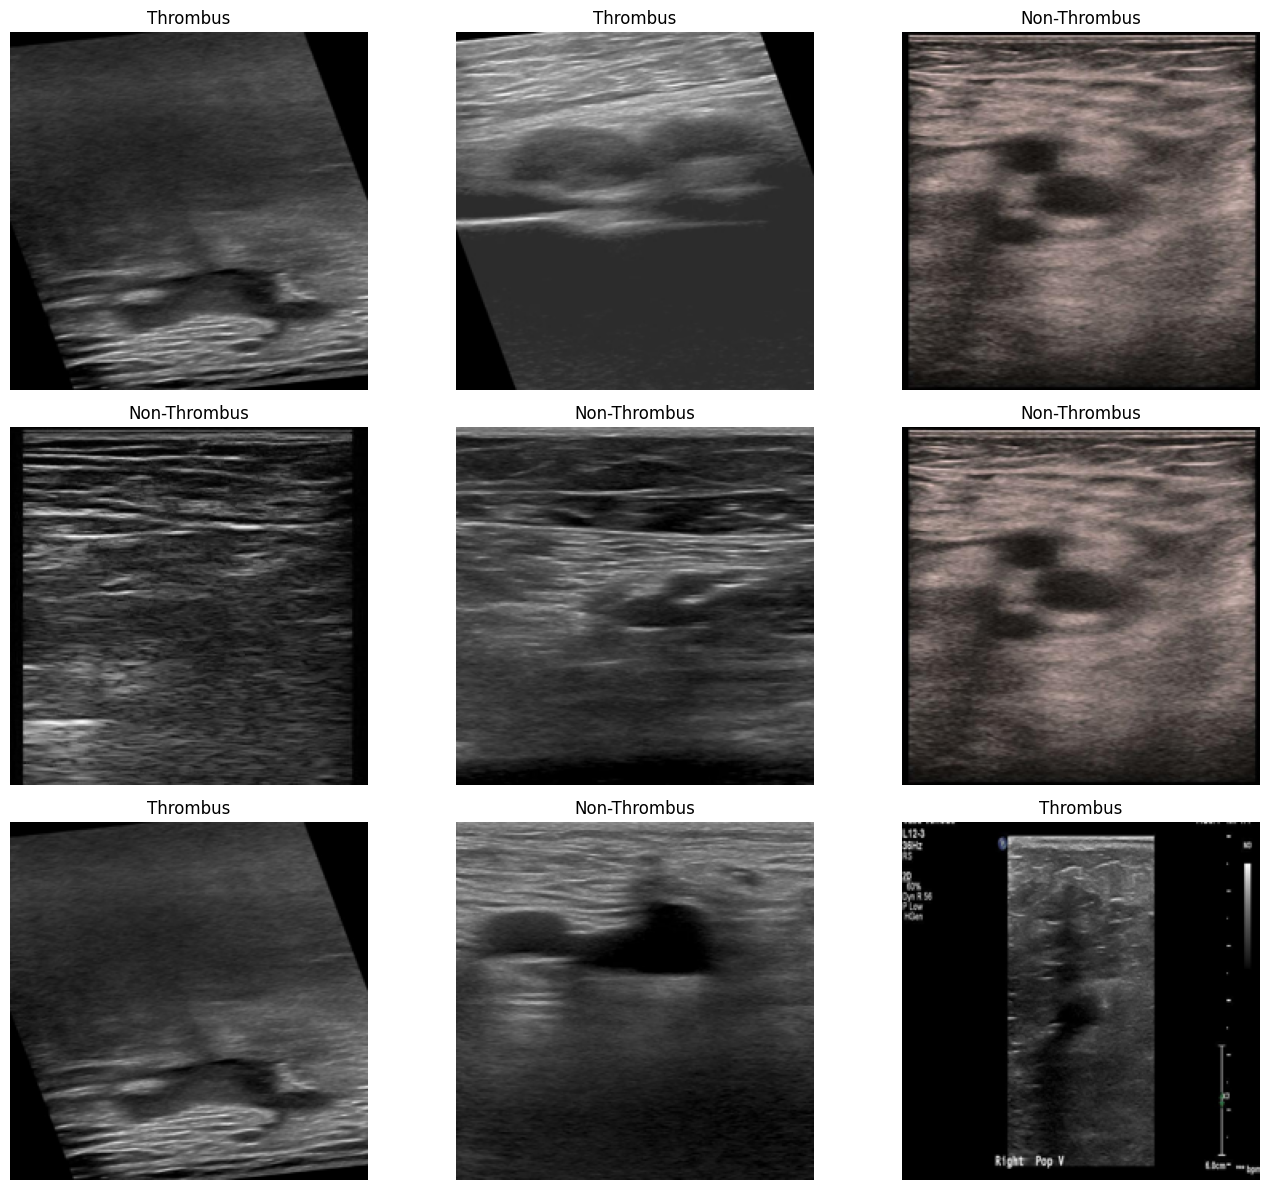


ESTATÍSTICAS DOS PIXELS (TRAIN):
Mín: 0.0000 | Máx: 255.0000
Média: 49.5022 | Desvio Padrão: 44.9796
Shape: (800, 224, 224, 3) (Amostras, Altura, Largura, Canais RGB)


In [ ]:
# Visualizar imagens pré-processadas
fig, axes = plt.subplots(3, 3, figsize=(14, 12))
indices = [0, X_train.shape[0]//4, X_train.shape[0]//2, 
           X_train.shape[0]//4*3, X_train.shape[0]-1, 
           np.where(y_train==0)[0][0], np.where(y_train==1)[0][0],
           np.where(y_train==0)[0][10], np.where(y_train==1)[0][10]]

for idx, ax in enumerate(axes.flat):
    if idx < len(indices):
        img = X_train[indices[idx]]
        label = "Thrombus" if y_train[indices[idx]] == 1 else "Non-Thrombus"
        ax.imshow(img)
        ax.set_title(f"{label}")
        ax.axis('off')

plt.tight_layout()
plt.show()

# Estatísticas dos valores dos pixels
print("\nESTATÍSTICAS DOS PIXELS (TRAIN):")
print(f"Mín: {X_train.min():.4f} | Máx: {X_train.max():.4f}")
print(f"Média: {X_train.mean():.4f} | Desvio Padrão: {X_train.std():.4f}")
print(f"Shape: {X_train.shape} (Amostras, Altura, Largura, Canais RGB)")

In [ ]:
output_dir = Path('dados_preprocessados')
output_dir.mkdir(exist_ok=True)

# Salvar em formato .npz 
np.savez_compressed(
    output_dir / 'dataset_completo.npz',
    X_train=X_train, y_train=y_train,
    X_test=X_test, y_test=y_test
)

print(f"Dataset completo salvo em: {output_dir / 'dataset_completo.npz'}")
np.savez_compressed(output_dir / 'train.npz', X=X_train, y=y_train)
np.savez_compressed(output_dir / 'test.npz', X=X_test, y=y_test)
# Criar arquivo de configuração
config = {
    'img_size': IMG_SIZE,
    'num_classes': 2,
    'class_names': ['Não Trombose', 'Trombose'],
    'num_canais': 3,
    'normalizado': True,
    'range': '[0.0, 1.0]',
    'train_samples': int(X_train.shape[0]),
    'test_samples': int(X_test.shape[0]),
    'valid_samples': int(X_valid.shape[0]),
}

import json
with open(output_dir / 'config.json', 'w') as f:
    json.dump(config, f, indent=2, ensure_ascii=False)


In [ ]:
X_train_loaded, y_train_loaded, X_test_loaded, y_test_loaded= carregar_dados_preprocessados()

# Modelo

In [ ]:
data = np.load('dados_preprocessados/dataset_completo.npz')
X_all = data['X_train'].astype(np.float32)
y_all = data['y_train'].astype(np.int32)
X_test = data['X_test'].astype(np.float32)
y_test = data['y_test'].astype(np.int32)

X_train, X_valid, y_train, y_valid = train_test_split(
    X_all, y_all, test_size=0.2, stratify=y_all, random_state=42
)

print(f"Train: {X_train.shape} | classes: {np.bincount(y_train)}")
print(f"Valid: {X_valid.shape} | classes: {np.bincount(y_valid)}")
print(f"Test:  {X_test.shape}  | classes: {np.bincount(y_test)}")


cw = compute_class_weight('balanced', classes=np.array([0,1]), y=y_train)
class_weight_dict = {0: float(cw[0]), 1: float(cw[1])}
print(f"Class weights: {class_weight_dict}")


keras.backend.clear_session()

model = Sequential([
    Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(224,224,3)),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(64, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(128, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Conv2D(256, (3,3), activation='relu', padding='same'),
    BatchNormalization(),
    MaxPooling2D((2,2)),
    Dropout(0.25),

    Flatten(),
    Dense(256, activation='relu'),
    Dropout(0.5),
    Dense(1, activation='sigmoid')
], name='thrombus_cnn')


model.compile(
    optimizer=Adam(learning_rate=0.0001),
    loss='binary_crossentropy',
    metrics=[
        'accuracy',
        tf.keras.metrics.AUC(name='auc'),
        tf.keras.metrics.Precision(name='precision'),
        tf.keras.metrics.Recall(name='recall')
    ]
)
model.summary()


callbacks = [
    keras.callbacks.EarlyStopping(
        monitor='val_auc', patience=15, mode='max',
        restore_best_weights=True, verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor='val_auc', factor=0.5, patience=7,
        mode='max', min_lr=1e-7, verbose=1
    ),
    keras.callbacks.ModelCheckpoint(
        'melhor_modelo.keras', monitor='val_auc',
        mode='max', save_best_only=True, verbose=1
    )
]

history = model.fit(
    X_train, y_train,                    # numpy direto
    validation_data=(X_valid, y_valid),  # numpy direto
    epochs=100,
    batch_size=32,
    class_weight=class_weight_dict,
    callbacks=callbacks,
    verbose=1
)


# THRESHOLD ÓTIMO
y_prob_valid = model.predict(X_valid, batch_size=32).flatten()
fpr, tpr, thresholds_roc = roc_curve(y_valid, y_prob_valid)
youden_idx = np.argmax(tpr - fpr)
best_threshold = float(thresholds_roc[youden_idx])

print(f"\nThreshold ótimo: {best_threshold:.4f}")
print(f"  Sensibilidade : {tpr[youden_idx]:.4f}")
print(f"  Especificidade: {1 - fpr[youden_idx]:.4f}")

# AVALIAÇÃO FINAL
y_prob_test = model.predict(X_test, batch_size=32).flatten()
y_pred_05  = (y_prob_test >= 0.5).astype(int)
y_pred_opt = (y_prob_test >= best_threshold).astype(int)

print("\n📋 Threshold = 0.5:")
print(classification_report(y_test, y_pred_05,
                             target_names=['Não Trombose', 'Trombose']))

print(f"\n📋 Threshold ótimo = {best_threshold:.4f}:")
print(classification_report(y_test, y_pred_opt,
                             target_names=['Não Trombose', 'Trombose']))

print(f"AUC: {roc_auc_score(y_test, y_prob_test):.4f}")

Train: (640, 224, 224, 3) | classes: [320 320]
Valid: (160, 224, 224, 3) | classes: [80 80]
Test:  (200, 224, 224, 3)  | classes: [100 100]
Class weights: {0: 1.0, 1: 1.0}


Model: "thrombus_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 224, 224, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 224, 224, 32)   │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 112, 112, 32)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 112, 112, 64)   │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 112, 112, 64)   │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 56, 56, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 56, 56, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 56, 56, 128)    │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 28, 28, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_3 (Conv2D)               │ (None, 28, 28, 256)    │       295,168 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_3           │ (None, 28, 28, 256)    │         1,024 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 14, 14, 256)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 50176)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │    12,845,312 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │           257 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 13,235,905 (50.49 MB)

 Trainable params: 13,234,945 (50.49 MB)

 Non-trainable params: 960 (3.75 KB)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 75ms/step - accuracy: 0.5932 - auc: 0.5960 - loss: 1.8494 - precision: 0.5887 - recall: 0.5671
Epoch 1: val_auc improved from None to 0.59281, saving model to melhor_modelo.keras

Epoch 1: finished saving model to melhor_modelo.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 15s 218ms/step - accuracy: 0.6422 - auc: 0.6739 - loss: 1.2489 - precision: 0.6409 - recall: 0.6469 - val_accuracy: 0.5000 - val_auc: 0.5928 - val_loss: 0.7884 - val_precision: 0.0000e+00 - val_recall: 0.0000e+00 - learning_rate: 1.0000e-04
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 81ms/step - accuracy: 0.7074 - auc: 0.7677 - loss: 0.6987 - precision: 0.7344 - recall: 0.6557
Epoch 2: val_auc improved from 0.59281 to 0.64797, saving model to melhor_modelo.keras

Epoch 2: finished saving model to melhor_modelo.keras
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 144ms/step - accuracy: 0.7125 - auc: 0.7753 - loss: 0.6453 - precision: 0.7237 - recall: 0.6875 - val_accuracy: 0.5000 - val_auc: 0.6480 - val_loss

In [ ]:
model.save('dados_preprocessados/modelo_final.keras')
np.savez_compressed('dados_preprocessados/history_final.npz', history=history.history)

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

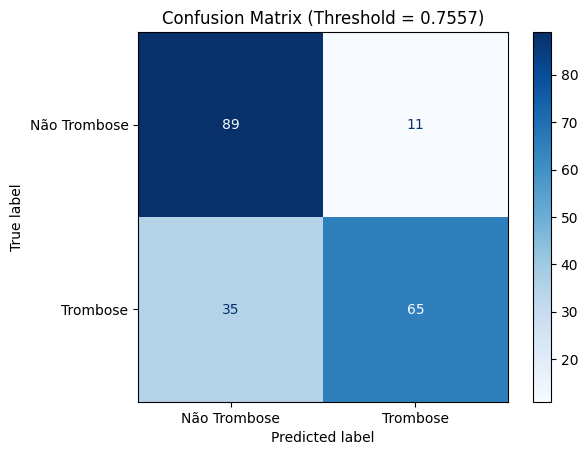

In [ ]:
cm = confusion_matrix(y_test, y_pred_opt)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Não Trombose', 'Trombose'])
disp.plot(cmap=plt.cm.Blues)
plt.title(f'Confusion Matrix (Threshold = {best_threshold:.4f})')
plt.show()

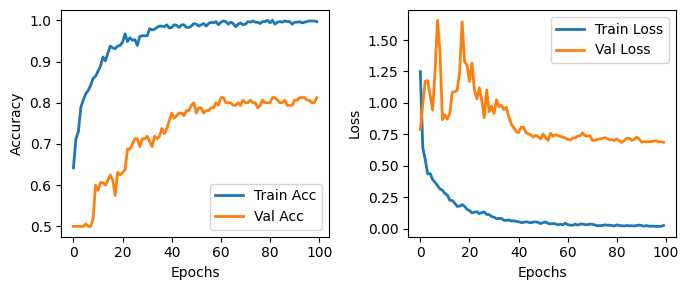

In [ ]:
plt.figure(figsize=(7, 3))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Acc', linewidth=2)
plt.plot(history.history['val_accuracy'], label='Val Acc',  linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Accuracy')
plt.legend()
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss',  linewidth=2)
plt.plot(history.history['val_loss'], label='Val Loss', linewidth=2)
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.tight_layout()
plt.show()

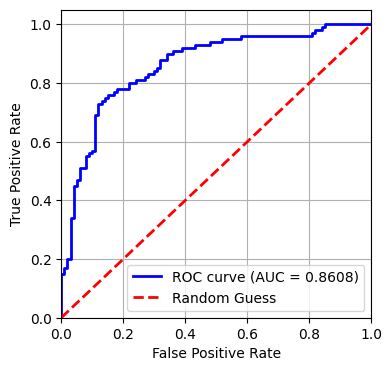

In [ ]:
fpr, tpr, _ = roc_curve(y_test, y_prob_test)
roc_auc = auc(fpr, tpr)
plt.figure(figsize=(4, 4))
plt.plot(fpr, tpr, color='blue', lw=2, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='red', lw=2, linestyle='--', label='Random Guess')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
#plt.title('ROC Curve')
plt.legend(loc='lower right')
plt.grid()
plt.show()

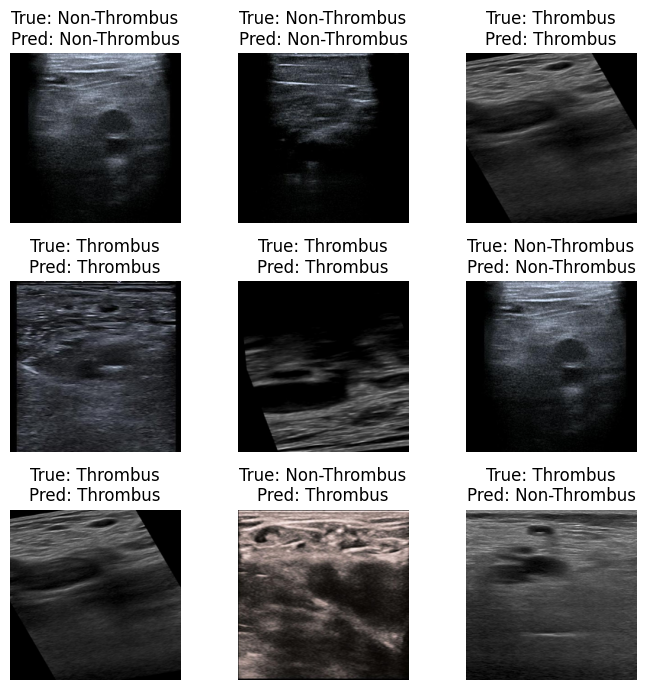

In [ ]:
fig, axes = plt.subplots(3, 3, figsize=(7, 7)) 
indices = [0, X_test.shape[0]//4, X_test.shape[0]//2, 
           X_test.shape[0]//4*3, X_test.shape[0]-1, 
           np.where(y_test==0)[0][0], np.where(y_test==1)[0][0],
           np.where(y_test==0)[0][10], np.where(y_test==1)[0][10]]
for idx, ax in enumerate(axes.flat):
    if idx < len(indices):
        img = X_test[indices[idx]]
        true_label = "Thrombus" if y_test[indices[idx]] == 1 else "Non-Thrombus"
        pred_label = "Thrombus" if y_pred_opt[indices[idx]] == 1 else "Non-Thrombus"
        ax.imshow(img)
        ax.set_title(f"True: {true_label}\nPred: {pred_label}")
        ax.axis('off')
plt.tight_layout()
plt.savefig('samples_test.eps', format='eps')
plt.show()

Calculando métricas completas...

  AVALIAÇÃO CLÍNICA COMPLETA — CNN Trombose
  n=200 | threshold=0.756 | bootstrap n=2000

Métrica                         Valor  IC 95%
-----------------------------------------------------------------
  Sensibilidade (Recall)       0.6500  [0.5556 – 0.7423]
  Especificidade               0.8900  [0.8229 – 0.9490]
  VPP (Precision)              0.8553  [0.7733 – 0.9325]
  VPN                          0.7177  [0.6339 – 0.7953]
  AUC-ROC                      0.8608  [0.8041 – 0.9114]
  AUC-PR                       0.8572  [0.7852 – 0.9195]
  MCC                          0.5563  [0.4321 – 0.6649]
  F1-Score                     0.7386
  F2-Score                     0.6828
  Youden Index                 0.5400
  LR+                          5.9091
  LR-                          0.3933
  DOR                         15.0260
  Brier Score                  0.1794
  Log-Loss                     0.9152
  Acurácia                     0.7700

Matriz de Confusão
  T

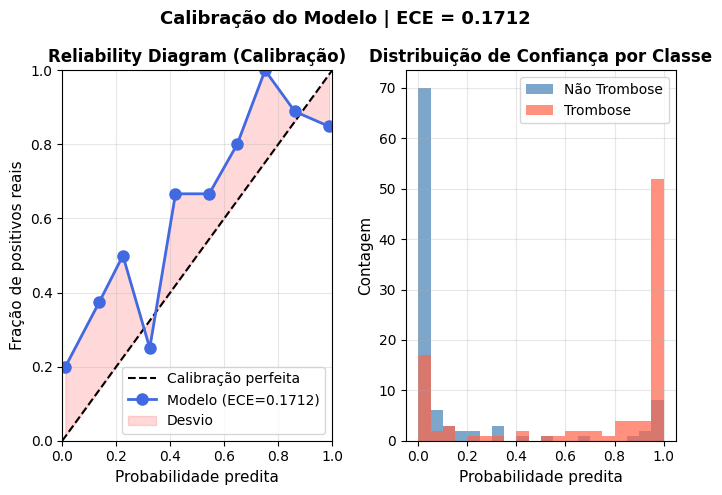

ECE (Expected Calibration Error): 0.1712
ECE < 0.05 = bem calibrado | ECE > 0.10 = mal calibrado

Gerando curvas com IC 95%...


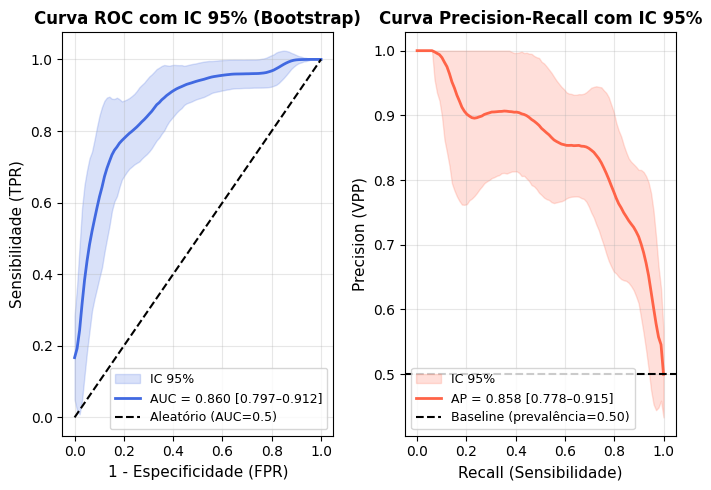

In [ ]:

def metricas_clinicas_completas(y_true, y_prob, threshold=0.5, 
                                 nome_modelo='Modelo', n_bootstrap=2000):
    """
    Conjunto completo de métricas com intervalo de confiança 95% via bootstrap.
    Padrão de publicações médicas (JAMA, Radiology, etc.)
    """
    y_pred = (y_prob >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    n = len(y_true)

    # MÉTRICAS BASE
    sensibilidade   = tp / (tp + fn)           # Recall / TPR
    especificidade  = tn / (tn + fp)           # TNR
    ppv             = tp / (tp + fp)           # Precision / Valor Preditivo Positivo
    npv             = tn / (tn + fn)           # Valor Preditivo Negativo
    acuracia        = (tp + tn) / n
    f1              = 2 * (ppv * sensibilidade) / (ppv + sensibilidade)
    f2              = 5 * (ppv * sensibilidade) / (4 * ppv + sensibilidade)  # penaliza FN
    mcc             = ((tp*tn) - (fp*fn)) / np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
    auc_roc         = roc_auc_score(y_true, y_prob)
    auc_pr          = average_precision_score(y_true, y_prob)  # melhor para desbalanceado
    brier           = brier_score_loss(y_true, y_prob)         # calibração
    logloss         = log_loss(y_true, y_prob)

    # Likelihood Ratios — essenciais para uso clínico
    lr_pos = sensibilidade / (1 - especificidade)   # LR+ > 10 é muito bom
    lr_neg = (1 - sensibilidade) / especificidade   # LR- < 0.1 é muito bom

    # Diagnostic Odds Ratio
    dor = (tp * tn) / (fp * fn) if (fp * fn) > 0 else np.inf

    # Youden Index
    youden = sensibilidade + especificidade - 1

    # INTERVALOS DE CONFIANÇA 95% VIA BOOTSTRAP
    def bootstrap_ci(y_true, y_prob, metric_fn, n_boot=n_bootstrap):
        scores = []
        rng = np.random.RandomState(42)
        for _ in range(n_boot):
            idx = rng.choice(len(y_true), len(y_true), replace=True)
            try:
                scores.append(metric_fn(y_true[idx], y_prob[idx]))
            except:
                pass
        scores = np.array(scores)
        return np.percentile(scores, 2.5), np.percentile(scores, 97.5)

    def sens_fn(yt, yp):
        yp_b = (yp >= threshold).astype(int)
        tn,fp,fn,tp = confusion_matrix(yt, yp_b).ravel()
        return tp/(tp+fn)

    def spec_fn(yt, yp):
        yp_b = (yp >= threshold).astype(int)
        tn,fp,fn,tp = confusion_matrix(yt, yp_b).ravel()
        return tn/(tn+fp)

    def ppv_fn(yt, yp):
        yp_b = (yp >= threshold).astype(int)
        tn,fp,fn,tp = confusion_matrix(yt, yp_b).ravel()
        return tp/(tp+fp) if (tp+fp)>0 else 0

    def npv_fn(yt, yp):
        yp_b = (yp >= threshold).astype(int)
        tn,fp,fn,tp = confusion_matrix(yt, yp_b).ravel()
        return tn/(tn+fn) if (tn+fn)>0 else 0

    def mcc_fn(yt, yp):
        yp_b = (yp >= threshold).astype(int)
        tn,fp,fn,tp = confusion_matrix(yt, yp_b).ravel()
        denom = np.sqrt((tp+fp)*(tp+fn)*(tn+fp)*(tn+fn))
        return ((tp*tn)-(fp*fn))/denom if denom>0 else 0

    print(f"\n{'='*65}")
    print(f"  AVALIAÇÃO CLÍNICA COMPLETA — {nome_modelo}")
    print(f"  n={n} | threshold={threshold:.3f} | bootstrap n={n_bootstrap}")
    print(f"{'='*65}")

    metricas = {
        'Sensibilidade (Recall)':  (sensibilidade,  bootstrap_ci(y_true, y_prob, sens_fn)),
        'Especificidade':          (especificidade,  bootstrap_ci(y_true, y_prob, spec_fn)),
        'VPP (Precision)':         (ppv,             bootstrap_ci(y_true, y_prob, ppv_fn)),
        'VPN':                     (npv,             bootstrap_ci(y_true, y_prob, npv_fn)),
        'AUC-ROC':                 (auc_roc,         bootstrap_ci(y_true, y_prob, roc_auc_score)),
        'AUC-PR':                  (auc_pr,          bootstrap_ci(y_true, y_prob, average_precision_score)),
        'MCC':                     (mcc,             bootstrap_ci(y_true, y_prob, mcc_fn)),
        'F1-Score':                (f1,              None),
        'F2-Score':                (f2,              None),
        'Youden Index':            (youden,          None),
        'LR+':                     (lr_pos,          None),
        'LR-':                     (lr_neg,          None),
        'DOR':                     (dor,             None),
        'Brier Score':             (brier,           None),
        'Log-Loss':                (logloss,         None),
        'Acurácia':                (acuracia,        None),
    }

    print(f"\n{'Métrica':<28} {'Valor':>8}  {'IC 95%'}")
    print(f"{'-'*65}")
    for nome, (val, ci) in metricas.items():
        if ci is not None:
            print(f"  {nome:<26} {val:>8.4f}  [{ci[0]:.4f} – {ci[1]:.4f}]")
        else:
            print(f"  {nome:<26} {val:>8.4f}")

    print(f"\n{'Matriz de Confusão':}")
    print(f"  TP={tp} | FP={fp}")
    print(f"  FN={fn} | TN={tn}")

    return metricas


# CALIBRAÇÃO DO MODELO (Reliability Diagram)
def plot_calibracao(y_true, y_prob, n_bins=10):
    """
    Reliability diagram — essencial para uso clínico.
    Modelo bem calibrado = linha diagonal perfeita.
    """
    from sklearn.calibration import calibration_curve

    fig, axes = plt.subplots(1, 2, figsize=(7, 5))

    # Reliability diagram
    prob_true, prob_pred = calibration_curve(y_true, y_prob, n_bins=n_bins)
    ece = np.mean(np.abs(prob_true - prob_pred))  # Expected Calibration Error

    axes[0].plot([0,1],[0,1], 'k--', lw=1.5, label='Calibração perfeita')
    axes[0].plot(prob_pred, prob_true, 'o-', color='royalblue',
                 lw=2, ms=8, label=f'Modelo (ECE={ece:.4f})')
    axes[0].fill_between(prob_pred, prob_true, prob_pred,
                          alpha=0.15, color='red', label='Desvio')
    axes[0].set_xlabel('Probabilidade predita', fontsize=11)
    axes[0].set_ylabel('Fração de positivos reais', fontsize=11)
    axes[0].set_title('Reliability Diagram (Calibração)', fontsize=12, fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)
    axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1)

    # Histograma de confiança
    axes[1].hist(y_prob[y_true==0], bins=20, alpha=0.7,
                 color='steelblue', label='Não Trombose')
    axes[1].hist(y_prob[y_true==1], bins=20, alpha=0.7,
                 color='tomato', label='Trombose')
    axes[1].set_xlabel('Probabilidade predita', fontsize=11)
    axes[1].set_ylabel('Contagem', fontsize=11)
    axes[1].set_title('Distribuição de Confiança por Classe', fontsize=12, fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.suptitle(f'Calibração do Modelo | ECE = {ece:.4f}',
                 fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig('calibracao.png', dpi=150, bbox_inches='tight')
    plt.show()
    print(f"ECE (Expected Calibration Error): {ece:.4f}")
    print("ECE < 0.05 = bem calibrado | ECE > 0.10 = mal calibrado")
    return ece


def plot_curvas_completas(y_true, y_prob, n_bootstrap=500):
    from sklearn.metrics import roc_curve, precision_recall_curve

    fig, axes = plt.subplots(1, 2, figsize=(7, 5))

    # --- Bootstrap para IC da ROC ---
    tprs, aucs_roc = [], []
    mean_fpr = np.linspace(0, 1, 100)
    rng = np.random.RandomState(42)

    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        fpr_b, tpr_b, _ = roc_curve(y_true[idx], y_prob[idx])
        tprs.append(np.interp(mean_fpr, fpr_b, tpr_b))
        aucs_roc.append(roc_auc_score(y_true[idx], y_prob[idx]))

    mean_tpr = np.mean(tprs, axis=0)
    std_tpr  = np.std(tprs, axis=0)

    axes[0].fill_between(mean_fpr, mean_tpr - 1.96*std_tpr,
                          mean_tpr + 1.96*std_tpr,
                          alpha=0.2, color='royalblue', label='IC 95%')
    axes[0].plot(mean_fpr, mean_tpr, color='royalblue', lw=2,
                 label=f'AUC = {np.mean(aucs_roc):.3f} [{np.percentile(aucs_roc,2.5):.3f}–{np.percentile(aucs_roc,97.5):.3f}]')
    axes[0].plot([0,1],[0,1],'k--', lw=1.5, label='Aleatório (AUC=0.5)')
    axes[0].set_xlabel('1 - Especificidade (FPR)', fontsize=11)
    axes[0].set_ylabel('Sensibilidade (TPR)', fontsize=11)
    axes[0].set_title('Curva ROC com IC 95% (Bootstrap)', fontsize=12, fontweight='bold')
    axes[0].legend(fontsize=9)
    axes[0].grid(True, alpha=0.3)

    # --- Precision-Recall ---
    precs, aps = [], []
    mean_rec = np.linspace(0, 1, 100)

    for _ in range(n_bootstrap):
        idx = rng.choice(len(y_true), len(y_true), replace=True)
        if len(np.unique(y_true[idx])) < 2:
            continue
        prec_b, rec_b, _ = precision_recall_curve(y_true[idx], y_prob[idx])
        precs.append(np.interp(mean_rec, rec_b[::-1], prec_b[::-1]))
        aps.append(average_precision_score(y_true[idx], y_prob[idx]))

    mean_prec = np.mean(precs, axis=0)
    std_prec  = np.std(precs, axis=0)
    baseline  = y_true.mean()

    axes[1].fill_between(mean_rec,
                          np.clip(mean_prec - 1.96*std_prec, 0, 1),
                          np.clip(mean_prec + 1.96*std_prec, 0, 1),
                          alpha=0.2, color='tomato', label='IC 95%')
    axes[1].plot(mean_rec, mean_prec, color='tomato', lw=2,
                 label=f'AP = {np.mean(aps):.3f} [{np.percentile(aps,2.5):.3f}–{np.percentile(aps,97.5):.3f}]')
    axes[1].axhline(baseline, color='k', linestyle='--', lw=1.5,
                    label=f'Baseline (prevalência={baseline:.2f})')
    axes[1].set_xlabel('Recall (Sensibilidade)', fontsize=11)
    axes[1].set_ylabel('Precision (VPP)', fontsize=11)
    axes[1].set_title('Curva Precision-Recall com IC 95%', fontsize=12, fontweight='bold')
    axes[1].legend(fontsize=9)
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('curvas_roc_pr.png', dpi=150, bbox_inches='tight')
    plt.show()


# MCNEMAR TEST — comparar dois modelos estatisticamente

def mcnemar_test(y_true, y_pred_A, y_pred_B, nome_A='Modelo A', nome_B='Modelo B'):
    """
    Teste de McNemar: determina se dois modelos diferem
    estatisticamente. Padrão em comparações de modelos médicos.
    """
    from statsmodels.stats.contingency_tables import mcnemar

    # Tabela de contingência
    b = np.sum((y_pred_A == y_true) & (y_pred_B != y_true))  # A certo, B errado
    c = np.sum((y_pred_A != y_true) & (y_pred_B == y_true))  # A errado, B certo

    table = [[0, b], [c, 0]]
    result = mcnemar(table, exact=True)

    print(f"\n{'='*50}")
    print(f"  TESTE DE McNEMAR: {nome_A} vs {nome_B}")
    print(f"{'='*50}")
    print(f"  {nome_A} certo, {nome_B} errado (b): {b}")
    print(f"  {nome_A} errado, {nome_B} certo (c): {c}")
    print(f"  p-valor: {result.pvalue:.4f}")
    if result.pvalue < 0.05:
        melhor = nome_A if b > c else nome_B
        print(f"  ✓ Diferença SIGNIFICATIVA (p<0.05) — {melhor} é superior")
    else:
        print(f"  ✗ Diferença NÃO significativa (p≥0.05)")
    return result.pvalue



print("Calculando métricas completas...")

metricas = metricas_clinicas_completas(
    y_true=y_test,
    y_prob=y_prob_test,
    threshold=best_threshold,
    nome_modelo='CNN Trombose',
    n_bootstrap=2000
)

print("\nAnalisando calibração...")
ece = plot_calibracao(y_test, y_prob_test)

print("\nGerando curvas com IC 95%...")
plot_curvas_completas(y_test, y_prob_test, n_bootstrap=500)

Modelo construído
Última conv: conv2d_3
5/5 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step
7/7 ━━━━━━━━━━━━━━━━━━━━ 0s 25ms/step
Threshold ótimo: 0.7557

📋 Relatório Final:
              precision    recall  f1-score   support

Não Trombose       0.72      0.89      0.79       100
    Trombose       0.86      0.65      0.74       100

    accuracy                           0.77       200
   macro avg       0.79      0.77      0.77       200
weighted avg       0.79      0.77      0.77       200

AUC: 0.8608


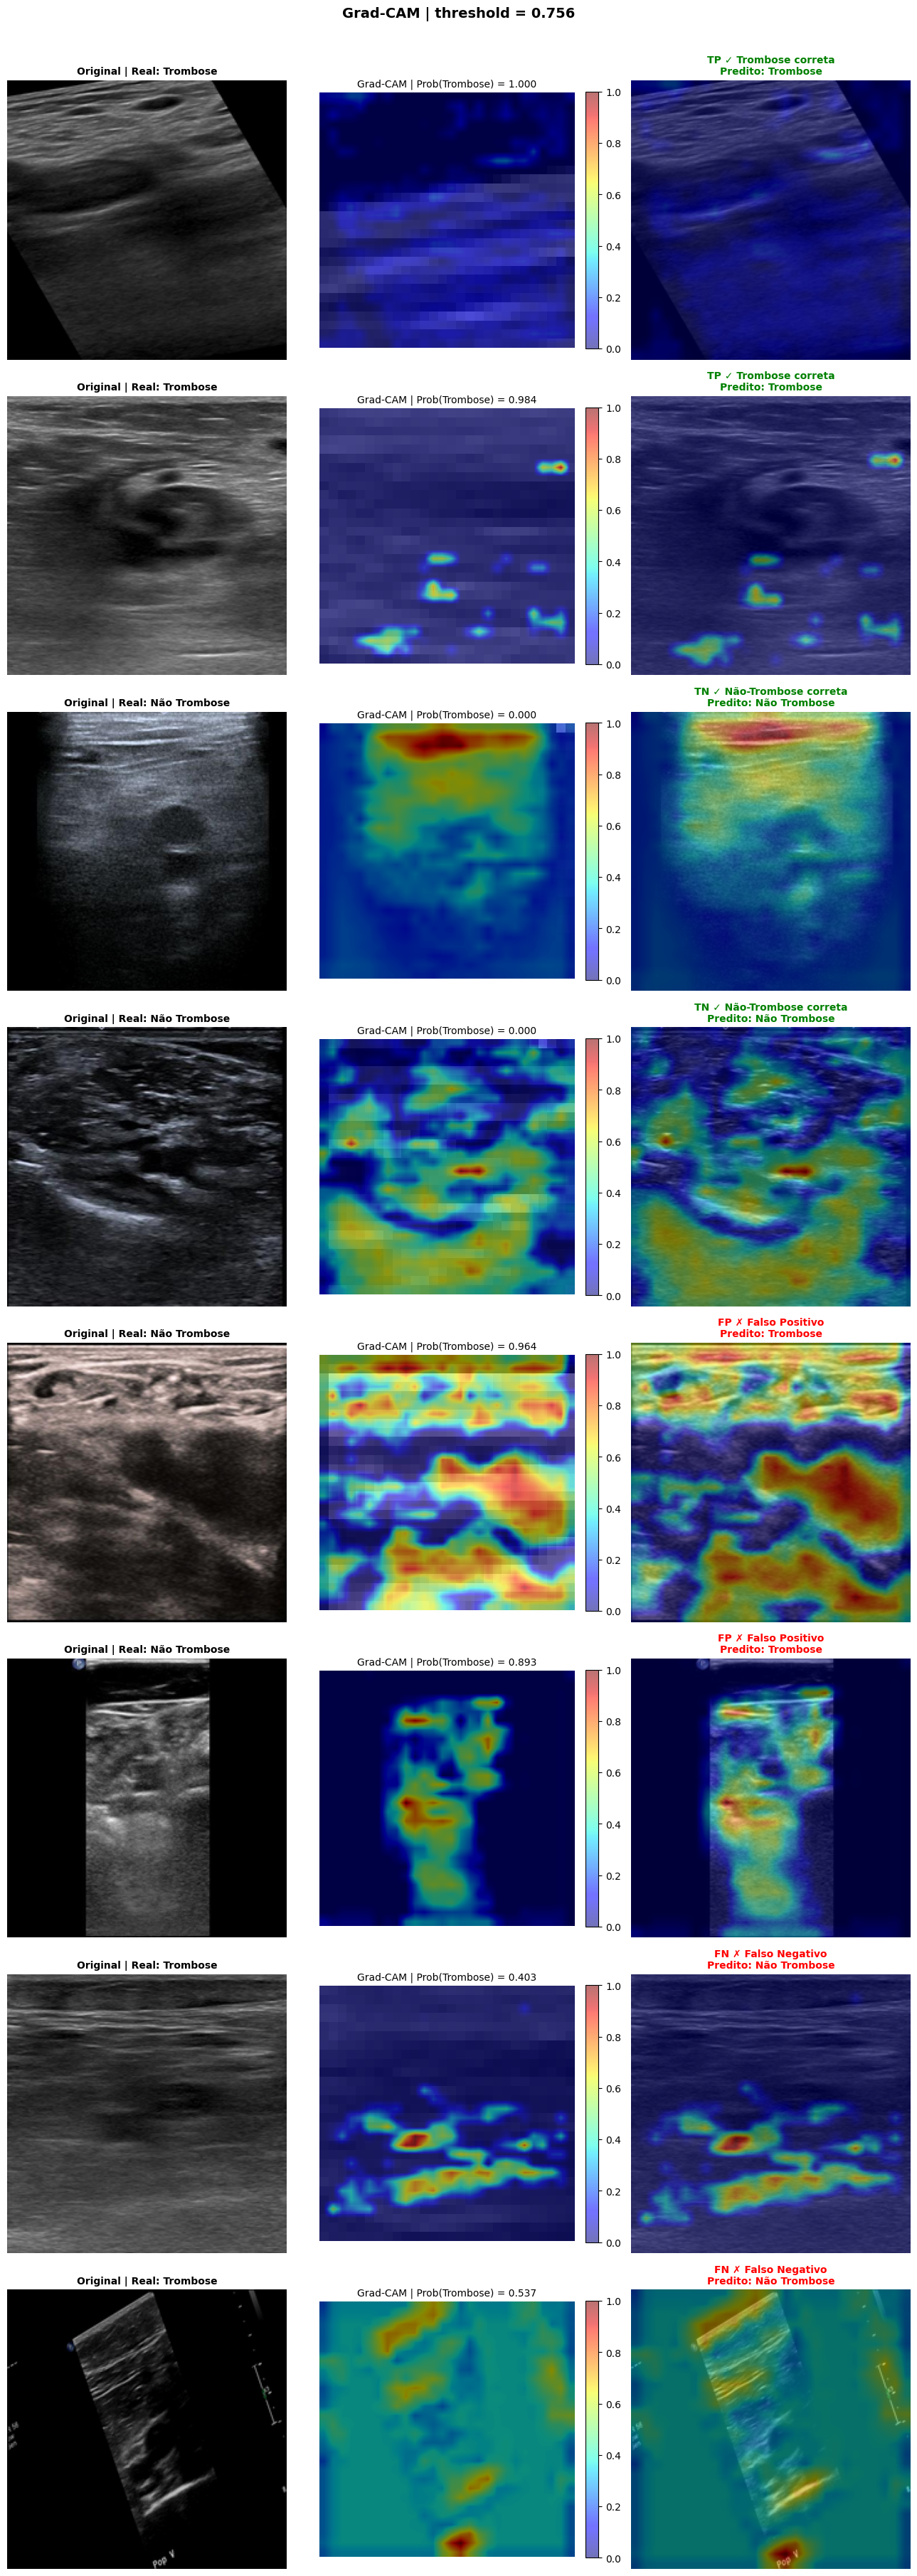

Salvo: gradcam_avaliacao.png


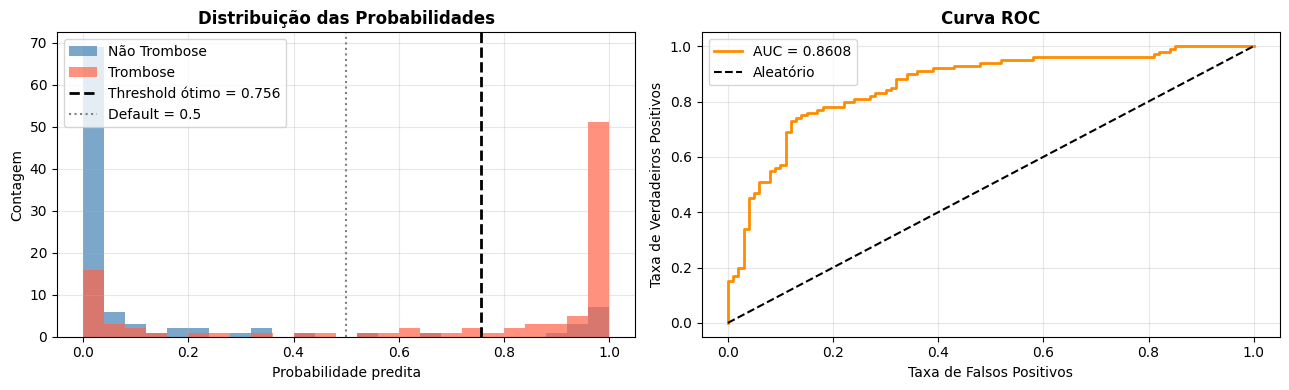

Salvo: roc_distribuicao.png


In [ ]:
import numpy as np
import tensorflow as tf
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from sklearn.metrics import roc_auc_score, roc_curve, classification_report


_ = model(tf.zeros((1, 224, 224, 3)), training=False)

# Última camada conv
conv_layers = [l.name for l in model.layers if 'conv2d' in l.name]
last_conv   = conv_layers[-1]
print(f"Última conv: {last_conv}")


def make_gradcam_heatmap(img, model, last_conv_layer_name):
    """img: (224, 224, 3) float32 em [0,1]"""

    # Construir modelo funcional explícito com Input layer
    inp          = tf.keras.Input(shape=(224, 224, 3))
    x            = inp
    conv_out     = None

    for layer in model.layers:
        x = layer(x)
        if layer.name == last_conv_layer_name:
            conv_out = x

    grad_model = tf.keras.Model(inputs=inp, outputs=[conv_out, x])

    img_tensor = tf.cast(img[np.newaxis, ...], tf.float32)

    with tf.GradientTape() as tape:
        conv_outputs, predictions = grad_model(img_tensor, training=False)
        loss = predictions[:, 0]

    grads        = tape.gradient(loss, conv_outputs)
    pooled_grads = tf.reduce_mean(grads, axis=(0, 1, 2))
    heatmap      = conv_outputs[0] @ pooled_grads[..., tf.newaxis]
    heatmap      = tf.squeeze(heatmap)
    heatmap      = tf.maximum(heatmap, 0)
    heatmap      = heatmap / (tf.reduce_max(heatmap) + 1e-8)
    return heatmap.numpy()


def overlay_gradcam(img, heatmap, alpha=0.45):
    heatmap_up = tf.image.resize(
        heatmap[..., np.newaxis], [224, 224]
    ).numpy().squeeze()
    colored  = cm.jet(heatmap_up)[:, :, :3]
    overlay  = colored * alpha + np.float32(img) * (1 - alpha)
    return np.clip(overlay, 0, 1)



def plot_gradcam_grid(X, y_true, y_prob, model, last_conv,
                      threshold=0.5, n_per_cat=2):

    y_pred = (y_prob >= threshold).astype(int)
    cats   = {
        'TP ✓ Trombose correta':     np.where((y_true==1)&(y_pred==1))[0],
        'TN ✓ Não-Trombose correta': np.where((y_true==0)&(y_pred==0))[0],
        'FP ✗ Falso Positivo':       np.where((y_true==0)&(y_pred==1))[0],
        'FN ✗ Falso Negativo':       np.where((y_true==1)&(y_pred==0))[0],
    }

    samples = []
    for cat_name, idxs in cats.items():
        cor = 'green' if '✓' in cat_name else 'red'
        for idx in idxs[:n_per_cat]:
            samples.append((idx, cat_name, cor))

    n     = len(samples)
    fig, axes = plt.subplots(n, 3, figsize=(13, 4.5 * n))
    if n == 1:
        axes = axes[np.newaxis, :]

    class_names = ['Não Trombose', 'Trombose']

    for row, (idx, cat_name, cor) in enumerate(samples):
        img      = X[idx]
        true_lbl = y_true[idx]
        prob     = y_prob[idx]
        heatmap  = make_gradcam_heatmap(img, model, last_conv)
        overlay  = overlay_gradcam(img, heatmap)

        axes[row, 0].imshow(img, cmap='gray')
        axes[row, 0].set_title(
            f'Original | Real: {class_names[true_lbl]}',
            fontsize=10, fontweight='bold'
        )
        axes[row, 0].axis('off')

        axes[row, 1].imshow(img, cmap='gray')
        im = axes[row, 1].imshow(
            heatmap, cmap='jet', alpha=0.55,
            interpolation='bilinear', vmin=0, vmax=1
        )
        plt.colorbar(im, ax=axes[row, 1], fraction=0.046, pad=0.04)
        axes[row, 1].set_title(
            f'Grad-CAM | Prob(Trombose) = {prob:.3f}',
            fontsize=10
        )
        axes[row, 1].axis('off')

        axes[row, 2].imshow(overlay)
        axes[row, 2].set_title(
            f'{cat_name}\nPredito: {class_names[int(prob >= threshold)]}',
            fontsize=10, color=cor, fontweight='bold'
        )
        axes[row, 2].axis('off')

    plt.suptitle(
        f'Grad-CAM | threshold = {threshold:.3f}',
        fontsize=14, fontweight='bold', y=1.005
    )
    plt.tight_layout()
    plt.savefig('gradcam_avaliacao.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Salvo: gradcam_avaliacao.png")



def plot_prob_distribution(y_true, y_prob, threshold):
    fig, axes = plt.subplots(1, 2, figsize=(13, 4))

    axes[0].hist(y_prob[y_true==0], bins=25, alpha=0.7,
                 label='Não Trombose', color='steelblue')
    axes[0].hist(y_prob[y_true==1], bins=25, alpha=0.7,
                 label='Trombose', color='tomato')
    axes[0].axvline(threshold, color='black', linestyle='--', lw=2,
                    label=f'Threshold ótimo = {threshold:.3f}')
    axes[0].axvline(0.5, color='gray', linestyle=':', lw=1.5,
                    label='Default = 0.5')
    axes[0].set_xlabel('Probabilidade predita')
    axes[0].set_ylabel('Contagem')
    axes[0].set_title('Distribuição das Probabilidades', fontweight='bold')
    axes[0].legend()
    axes[0].grid(True, alpha=0.3)

    fpr_t, tpr_t, _ = roc_curve(y_true, y_prob)
    auc_val = roc_auc_score(y_true, y_prob)
    axes[1].plot(fpr_t, tpr_t, color='darkorange', lw=2,
                 label=f'AUC = {auc_val:.4f}')
    axes[1].plot([0,1],[0,1], 'k--', lw=1.5, label='Aleatório')
    axes[1].set_xlabel('Taxa de Falsos Positivos')
    axes[1].set_ylabel('Taxa de Verdadeiros Positivos')
    axes[1].set_title('Curva ROC', fontweight='bold')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.savefig('roc_distribuicao.png', dpi=150, bbox_inches='tight')
    plt.show()
    print("Salvo: roc_distribuicao.png")



y_prob_valid = model.predict(X_valid, batch_size=32).flatten()
y_prob_test  = model.predict(X_test,  batch_size=32).flatten()

fpr, tpr, thresholds_roc = roc_curve(y_valid, y_prob_valid)
best_threshold = float(thresholds_roc[np.argmax(tpr - fpr)])
print(f"Threshold ótimo: {best_threshold:.4f}")

print("\n📋 Relatório Final:")
y_pred_opt = (y_prob_test >= best_threshold).astype(int)
print(classification_report(y_test, y_pred_opt,
                             target_names=['Não Trombose', 'Trombose']))
print(f"AUC: {roc_auc_score(y_test, y_prob_test):.4f}")

plot_gradcam_grid(
    X=X_test, y_true=y_test, y_prob=y_prob_test,
    model=model, last_conv=last_conv,
    threshold=best_threshold, n_per_cat=2
)

plot_prob_distribution(y_test, y_prob_test, best_threshold)

In [ ]:
%pip install lime


  0%|          | 0/1000 [00:00<?, ?it/s]

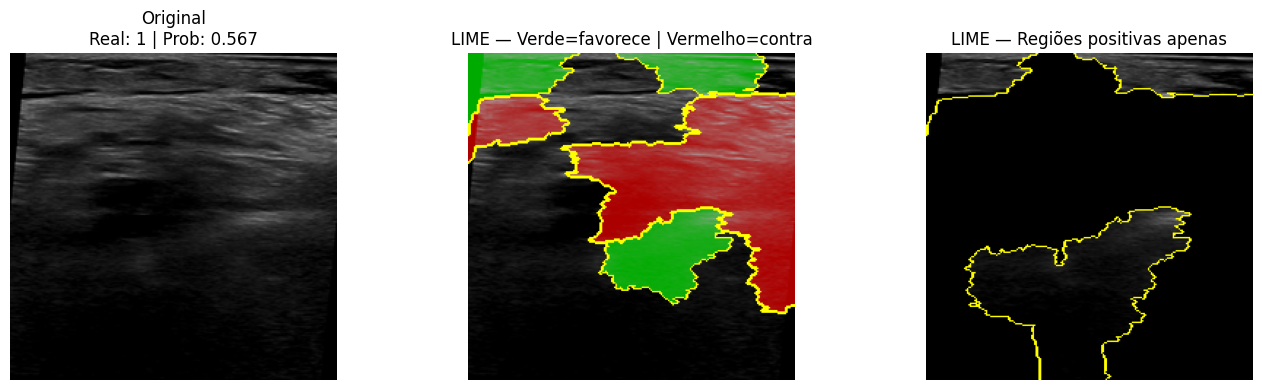

  0%|          | 0/1000 [00:00<?, ?it/s]

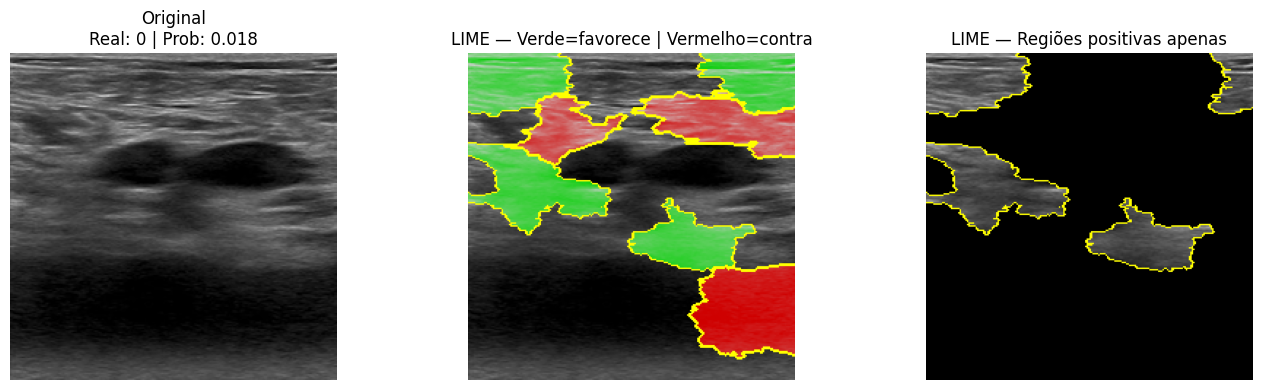

  0%|          | 0/1000 [00:00<?, ?it/s]

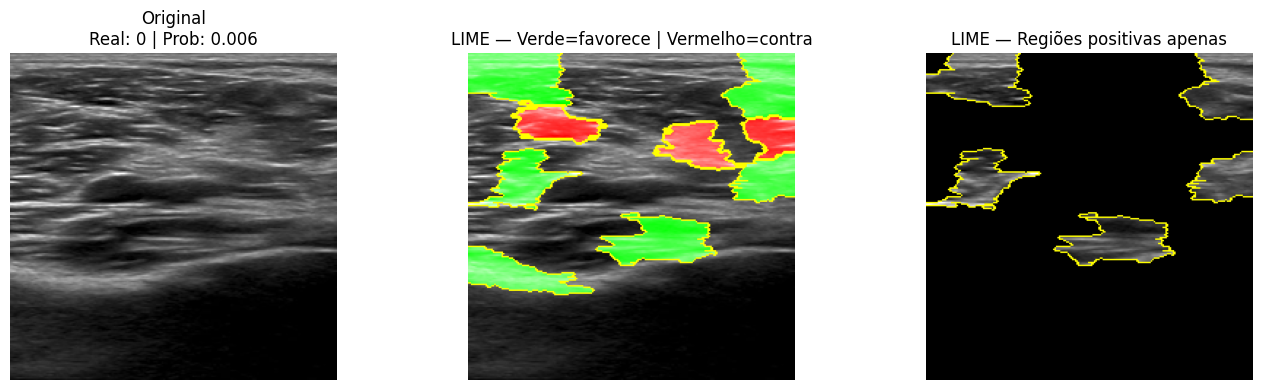

  0%|          | 0/1000 [00:00<?, ?it/s]

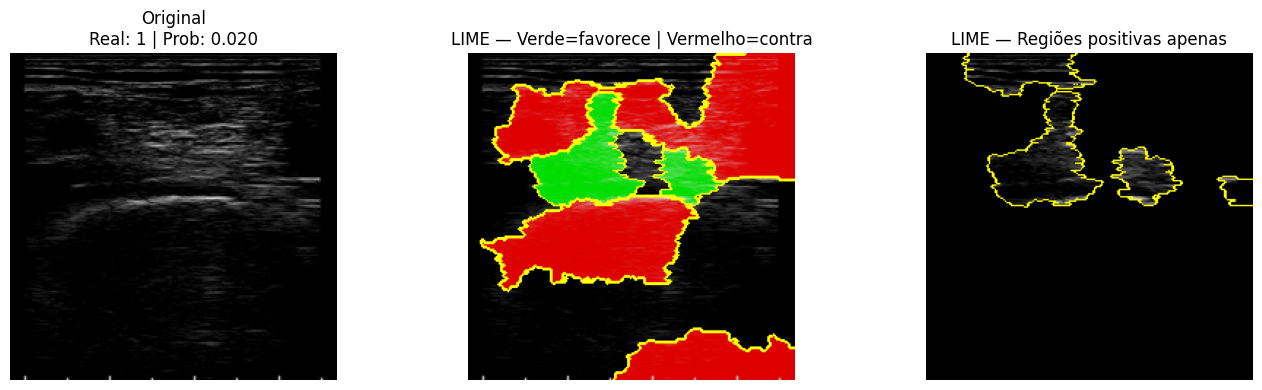

  0%|          | 0/1000 [00:00<?, ?it/s]

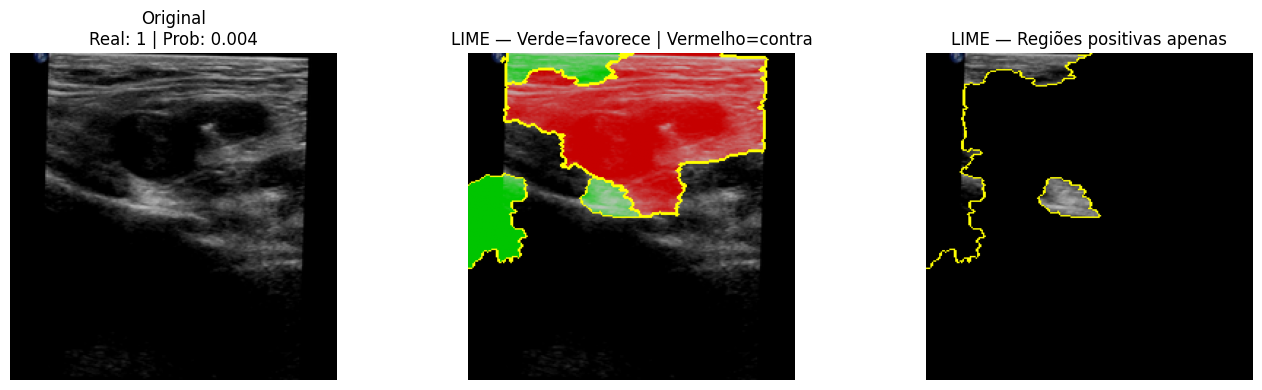

  0%|          | 0/1000 [00:00<?, ?it/s]

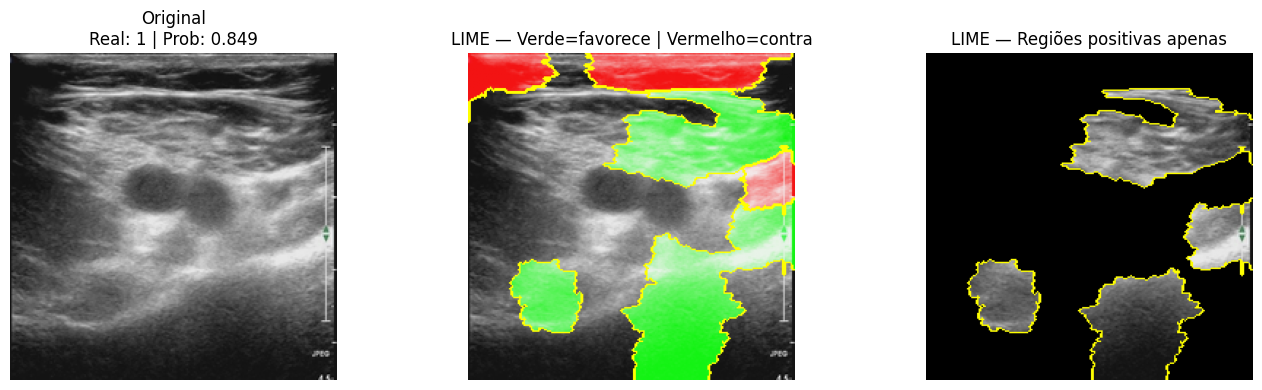

In [68]:

from lime import lime_image
from skimage.segmentation import mark_boundaries

explainer = lime_image.LimeImageExplainer()

def predict_fn(images):
    images = images.astype(np.float32) / 255.0 if images.max() > 1 else images.astype(np.float32)
    return np.column_stack([
        1 - model.predict(images, verbose=0).flatten(),
        model.predict(images, verbose=0).flatten()
    ])

def plot_lime(X, y_true, y_prob, idx, threshold=0.5):
    img   = X[idx]
    img_u = (img * 255).astype(np.uint8)

    explanation = explainer.explain_instance(
        img_u,
        predict_fn,
        top_labels=2,
        hide_color=0,
        num_samples=1000
    )

    label    = int(y_prob[idx] >= threshold)
    temp, mask = explanation.get_image_and_mask(
        label,
        positive_only=False,
        num_features=10,
        hide_rest=False
    )

    fig, axes = plt.subplots(1, 3, figsize=(14, 4))
    axes[0].imshow(img, cmap='gray')
    axes[0].set_title(f'Original\nReal: {y_true[idx]} | Prob: {y_prob[idx]:.3f}')
    axes[0].axis('off')

    axes[1].imshow(mark_boundaries(temp / 255.0, mask))
    axes[1].set_title('LIME — Verde=favorece | Vermelho=contra')
    axes[1].axis('off')

    # Só regiões que favorecem a predição
    temp2, mask2 = explanation.get_image_and_mask(
        label, positive_only=True, num_features=5, hide_rest=True
    )
    axes[2].imshow(mark_boundaries(temp2 / 255.0, mask2))
    axes[2].set_title('LIME — Regiões positivas apenas')
    axes[2].axis('off')

    plt.tight_layout()
    plt.show()

# Rodar em 6 exemplos
for idx in np.random.choice(len(X_test), 6, replace=False):
    plot_lime(X_test, y_test, y_prob_test, idx, best_threshold)